# DS605 – Lab Assignment 3
## Scikit-learn: Data Preprocessing and Model Performance Evaluation
**Dataset:** Kaggle Hotel Booking Demand (`hotel_bookings.csv`)

---
# Part A – Data Loading and Preprocessing


## Task 1 — Load and Understand the Dataset

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Load the dataset (place hotel_bookings.csv in the same folder as this notebook)
df = pd.read_csv("C:\\Msc Notes\\machiine learning\\Lab pracs\\prac_03\\hotel_bookings.csv")
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
print("Shape:", df.shape)


Shape: (119390, 32)


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [7]:
df.dtypes


hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

**Class distribution of the target `is_canceled`**

is_canceled
0    75166
1    44224
Name: count, dtype: int64

is_canceled
0    62.96
1    37.04
Name: proportion, dtype: float64


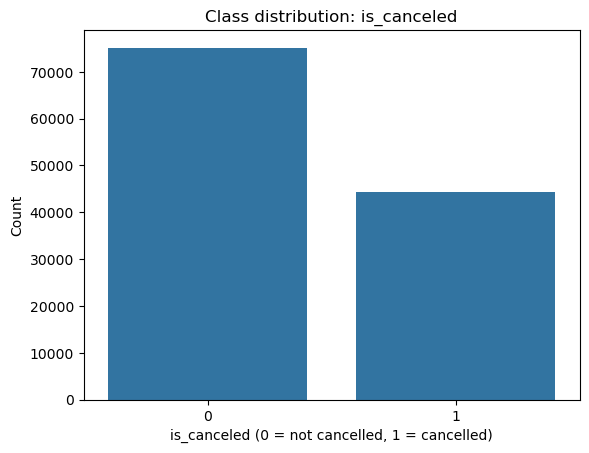

In [8]:
y_counts = df["is_canceled"].value_counts()
y_pct = df["is_canceled"].value_counts(normalize=True) * 100

print(y_counts)
print()
print(y_pct.round(2))

sns.countplot(x="is_canceled", data=df)
plt.title("Class distribution: is_canceled")
plt.xlabel("is_canceled (0 = not cancelled, 1 = cancelled)")
plt.ylabel("Count")
plt.show()


> The target is moderately imbalanced (~63% not-cancelled vs ~37% cancelled), which is why
> `stratify=y` is used later during the train/test split, and why precision/recall/F1 are
> reported alongside accuracy in Part B.

**Building `X` (features) and `y` (target), and separating numerical vs categorical columns**

`reservation_status` and `reservation_status_date` are excluded from `X` immediately — they
leak the final outcome of the booking (formalised again in Task 2).

In [9]:
target_col = "is_canceled"
leakage_cols = ["reservation_status", "reservation_status_date"]

y = df[target_col].copy()
X = df.drop(columns=[target_col] + leakage_cols)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (119390, 29)
y shape: (119390,)


In [13]:
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")


Numerical columns (19):
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns (10):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']


**Note on `agent`:** it is stored as a float column, but its values are booking-agent ID
codes, not a continuous quantity — it is nominal, not numerical. It is moved into the
categorical group so it is one-hot encoded (via `most_frequent` imputation + `OneHotEncoder`)
instead of being scaled as if the ID magnitude meant something.

In [14]:
numerical_cols.remove("agent")
categorical_cols.append("agent")

print(f"Numerical columns ({len(numerical_cols)}):\n{numerical_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}):\n{categorical_cols}")


Numerical columns (18):
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical columns (11):
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'agent']


## Task 2 — Missing Values, Leakage, and Outliers

**Missing-value count and percentage for every column**

In [16]:
missing_count = X.isnull().sum()
missing_pct = (X.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
company,112593,94.31
agent,16340,13.69
country,488,0.41
children,4,0.00


**High-missingness columns**

`company` is missing for ~94% of rows. A column missing for almost every row carries very
little usable signal, and imputing it would mostly mean inventing data, so it is dropped.
`agent` is missing for only ~14% of rows and is kept — its missing values are handled by the
`most_frequent` imputer for categorical columns (a missing `agent` most often just means a
direct booking, so a placeholder value is a reasonable stand-in rather than a reason to drop
the column). `country` (~0.4% missing) and `children` (4 rows) are trivial and kept as-is.

In [11]:
HIGH_MISSING_THRESHOLD = 50  # percent

high_missing_cols = missing_summary[
    missing_summary["missing_pct"] > HIGH_MISSING_THRESHOLD
].index.tolist()

print("Columns dropped for very high missingness (>{}%):".format(HIGH_MISSING_THRESHOLD),
      high_missing_cols)

X = X.drop(columns=high_missing_cols)
numerical_cols = [c for c in numerical_cols if c not in high_missing_cols]
categorical_cols = [c for c in categorical_cols if c not in high_missing_cols]

print("X shape after dropping high-missingness columns:", X.shape)


Columns dropped for very high missingness (>50%): ['company']
X shape after dropping high-missingness columns: (119390, 28)


**Leakage columns**

`reservation_status` and `reservation_status_date` were already excluded when `X` was built in
Task 1 — they record the *final* outcome of the booking and the date it was recorded, so using
them as features would let the model see the answer directly.

In [12]:
assert "reservation_status" not in X.columns
assert "reservation_status_date" not in X.columns
print("Confirmed: leakage columns are not present in X.")


Confirmed: leakage columns are not present in X.


**Outlier check on selected numerical features (boxplots + IQR method)**

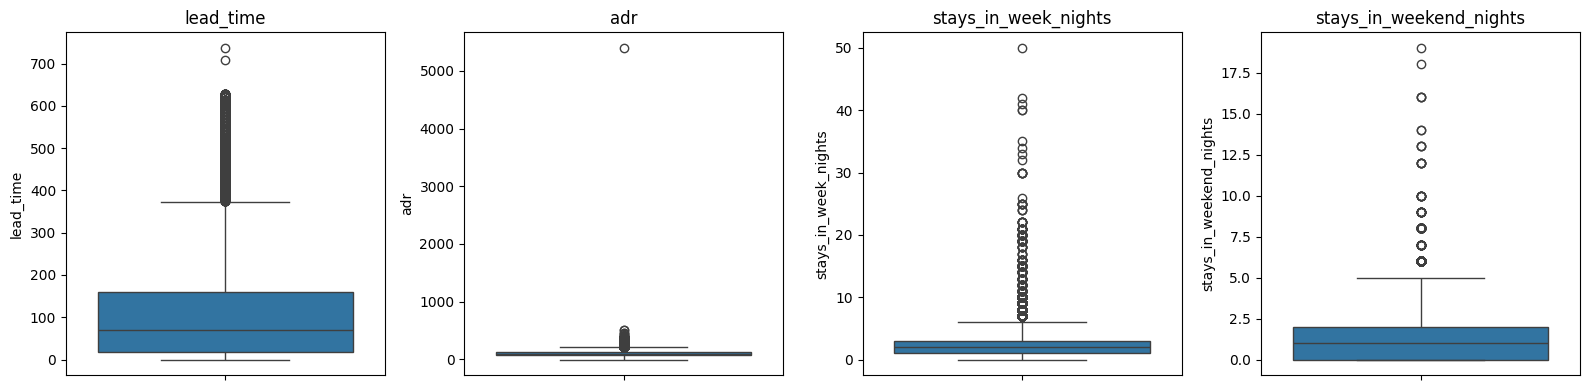

In [13]:
outlier_features = ["lead_time", "adr", "stays_in_week_nights", "stays_in_weekend_nights"]
outlier_features = [c for c in outlier_features if c in X.columns]

fig, axes = plt.subplots(1, len(outlier_features), figsize=(4 * len(outlier_features), 4))
for ax, col in zip(axes, outlier_features):
    sns.boxplot(y=X[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [14]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

for col in outlier_features:
    lower, upper = iqr_bounds(X[col])
    n_out = ((X[col] < lower) | (X[col] > upper)).sum()
    print(f"{col:25s} bounds=({lower:.1f}, {upper:.1f})  potential IQR outliers={n_out}")


lead_time                 bounds=(-195.0, 373.0)  potential IQR outliers=3005
adr                       bounds=(-15.8, 211.1)  potential IQR outliers=3793
stays_in_week_nights      bounds=(-2.0, 6.0)  potential IQR outliers=3354
stays_in_weekend_nights   bounds=(-3.0, 5.0)  potential IQR outliers=265


**Removing only clear/extreme outliers**

The strict 1.5×IQR rule flags a large number of rows here (e.g. thousands of otherwise
legitimate longer stays and higher `adr` bookings), so removing everything it flags would
throw away real signal. Instead only clearly implausible/extreme records are removed:
- `adr` that is negative or unrealistically high (data-entry errors — one row is negative,
  one row sits at 5,400 while the 75th percentile is ~126),
- `lead_time` beyond 500 days, or nights-stayed values that are extreme multi-week outliers.

Thresholds are set generously so only the most extreme rows are removed.

In [15]:
rows_before = X.shape[0]

extreme_mask = (
    (X["adr"] < 0) |
    (X["adr"] > 5000) |
    (X["lead_time"] > 500) |
    (X["stays_in_week_nights"] > 30) |
    (X["stays_in_weekend_nights"] > 10)
)

print("Extreme rows flagged:", extreme_mask.sum())

X = X.loc[~extreme_mask].reset_index(drop=True)
y = y.loc[~extreme_mask].reset_index(drop=True)

rows_after = X.shape[0]
print(f"Rows removed: {rows_before - rows_after} (before={rows_before}, after={rows_after})")


Extreme rows flagged: 498
Rows removed: 498 (before=119390, after=118892)


**Saving the cleaned base dataset** (required deliverable: *"the cleaned base dataset used
for modeling"*).

In [16]:
cleaned_df = X.copy()
cleaned_df.insert(0, "is_canceled", y.values)
cleaned_df.to_csv("hotel_bookings_cleaned.csv", index=False)
print("Saved hotel_bookings_cleaned.csv with shape:", cleaned_df.shape)


Saved hotel_bookings_cleaned.csv with shape: (118892, 29)


## Task 3 — Two Preprocessing Pipelines

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True).round(3))
print("Test class balance:\n", y_test.value_counts(normalize=True).round(3))


X_train: (95113, 28)  X_test: (23779, 28)
Train class balance:
 is_canceled
0    0.632
1    0.368
Name: proportion, dtype: float64
Test class balance:
 is_canceled
0    0.632
1    0.368
Name: proportion, dtype: float64


In [18]:
print("Numerical:", numerical_cols)
print("Categorical:", categorical_cols)


Numerical: ['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
Categorical: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type', 'agent']


In [19]:
# --- Pipeline A: KNNImputer + StandardScaler for numerical features ---
numeric_transformer_A = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor_A = ColumnTransformer(transformers=[
    ("num", numeric_transformer_A, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])

# --- Pipeline B: KNNImputer + MinMaxScaler for numerical features ---
numeric_transformer_B = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5)),
    ("scaler", MinMaxScaler()),
])

preprocessor_B = ColumnTransformer(transformers=[
    ("num", numeric_transformer_B, numerical_cols),
    ("cat", categorical_transformer, categorical_cols),
])

preprocessor_A, preprocessor_B


(ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('imputer', KNNImputer()),
                                                  ('scaler', StandardScaler())]),
                                  ['lead_time', 'arrival_date_year',
                                   'arrival_date_week_number',
                                   'arrival_date_day_of_month',
                                   'stays_in_weekend_nights',
                                   'stays_in_week_nights', 'adults', 'children',
                                   'babies', 'is_repeated_guest',
                                   'previous_cancellations',
                                   'previous_bookings_not_cancel...
                                   'adr', 'required_car_parking_spaces',
                                   'total_of_special_requests']),
                                 ('cat',
                                  Pipeline(steps=[('imputer',
                        

Both `ColumnTransformer`s will only ever be `.fit()` on the training split — each is wrapped
together with a model inside a single `sklearn.pipeline.Pipeline` in Part B, and `.fit(X_train,
y_train)` fits every step (imputers, scaler, encoder, model) on the training data only. The test
split only ever goes through `.transform()` / `.predict()`.

---
# Part B – Model Training and Performance Evaluation


## Task 4 — Train Two Classification Models (× two pipelines = four combinations)

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

preprocessors = {
    "Pipeline A (StandardScaler)": preprocessor_A,
    "Pipeline B (MinMaxScaler)": preprocessor_B,
}

def make_model(kind):
    if kind == "LogisticRegression":
        return LogisticRegression(max_iter=1000)
    elif kind == "DecisionTree":
        return DecisionTreeClassifier(random_state=42)
    raise ValueError(kind)

model_kinds = ["LogisticRegression", "DecisionTree"]

fitted_pipelines = {}

for prep_name, prep in preprocessors.items():
    for kind in model_kinds:
        clf = Pipeline(steps=[
            ("preprocess", prep),
            ("model", make_model(kind)),
        ])
        clf.fit(X_train, y_train)
        key = f"{kind} + {prep_name}"
        fitted_pipelines[key] = clf
        print("Trained:", key)


Trained: LogisticRegression + Pipeline A (StandardScaler)


Trained: DecisionTree + Pipeline A (StandardScaler)


Trained: LogisticRegression + Pipeline B (MinMaxScaler)


Trained: DecisionTree + Pipeline B (MinMaxScaler)


## Task 5 — Evaluate and Compare the Four Results

In [21]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

results = []

for name, clf in fitted_pipelines.items():
    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)

    results.append({
        "Model + Pipeline": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Precision (test)": round(precision, 4),
        "Recall (test)": round(recall, 4),
        "F1-score (test)": round(f1, 4),
        "Train-Test Gap": round(train_acc - test_acc, 4),
    })

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model + Pipeline,Train Accuracy,Test Accuracy,Precision (test),Recall (test),F1-score (test),Train-Test Gap
0,DecisionTree + Pipeline B (MinMaxScaler),0.9962,0.8652,0.8151,0.8201,0.8176,0.1310
1,DecisionTree + Pipeline A (StandardScaler),0.9962,0.8650,0.8152,0.8193,0.8173,0.1312
2,LogisticRegression + Pipeline A (StandardScaler),0.8334,0.8301,0.8107,0.7033,0.7532,0.0033
3,LogisticRegression + Pipeline B (MinMaxScaler),0.8285,0.8250,0.8047,0.6933,0.7449,0.0035


In [22]:
results_df.to_csv("model_comparison_table.csv", index=False)
print("Saved model_comparison_table.csv")


Saved model_comparison_table.csv


**Overfitting check.** The `Train-Test Gap` column (train accuracy − test accuracy) is the
signal to watch: a small gap means the model generalises about as well on unseen data as on
data it was trained on, while a large gap means the model has memorised training-specific
patterns. This is inspected concretely in the printed output above and discussed again in Task
6 below, once the actual numbers for this run are in.

**Confusion matrices for the best Logistic Regression result and the best Decision Tree result**

In [23]:
lr_rows = results_df[results_df["Model + Pipeline"].str.startswith("LogisticRegression")]
dt_rows = results_df[results_df["Model + Pipeline"].str.startswith("DecisionTree")]

best_lr_name = lr_rows.sort_values("Test Accuracy", ascending=False).iloc[0]["Model + Pipeline"]
best_dt_name = dt_rows.sort_values("Test Accuracy", ascending=False).iloc[0]["Model + Pipeline"]

print("Best Logistic Regression combination:", best_lr_name)
print("Best Decision Tree combination:", best_dt_name)


Best Logistic Regression combination: LogisticRegression + Pipeline A (StandardScaler)
Best Decision Tree combination: DecisionTree + Pipeline B (MinMaxScaler)


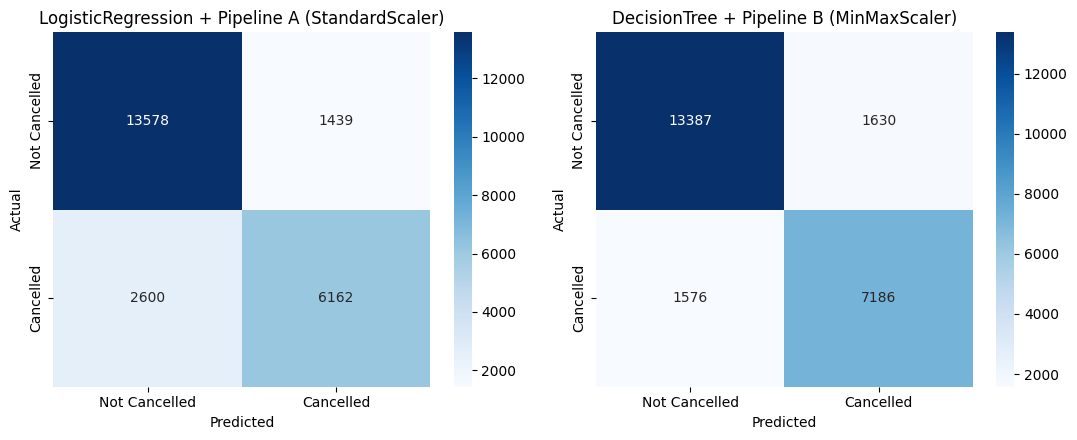

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, name in zip(axes, [best_lr_name, best_dt_name]):
    clf = fitted_pipelines[name]
    cm = confusion_matrix(y_test, clf.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Cancelled", "Cancelled"],
                yticklabels=["Not Cancelled", "Cancelled"], ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


## Task 6 — Final Observations

In [25]:
print(results_df.to_string(index=False))


                                Model + Pipeline  Train Accuracy  Test Accuracy  Precision (test)  Recall (test)  F1-score (test)  Train-Test Gap
        DecisionTree + Pipeline B (MinMaxScaler)          0.9962         0.8652            0.8151         0.8201           0.8176          0.1310
      DecisionTree + Pipeline A (StandardScaler)          0.9962         0.8650            0.8152         0.8193           0.8173          0.1312
LogisticRegression + Pipeline A (StandardScaler)          0.8334         0.8301            0.8107         0.7033           0.7532          0.0033
  LogisticRegression + Pipeline B (MinMaxScaler)          0.8285         0.8250            0.8047         0.6933           0.7449          0.0035


In [26]:
# Scaler effect on Logistic Regression: compare test accuracy / F1 for LR under A vs B
lr_A = results_df[results_df["Model + Pipeline"] == "LogisticRegression + Pipeline A (StandardScaler)"]
lr_B = results_df[results_df["Model + Pipeline"] == "LogisticRegression + Pipeline B (MinMaxScaler)"]
dt_A = results_df[results_df["Model + Pipeline"] == "DecisionTree + Pipeline A (StandardScaler)"]
dt_B = results_df[results_df["Model + Pipeline"] == "DecisionTree + Pipeline B (MinMaxScaler)"]

print("Logistic Regression — StandardScaler vs MinMaxScaler (test accuracy):")
print(lr_A[["Model + Pipeline", "Test Accuracy", "F1-score (test)"]].to_string(index=False))
print(lr_B[["Model + Pipeline", "Test Accuracy", "F1-score (test)"]].to_string(index=False))
print()
print("Decision Tree — StandardScaler vs MinMaxScaler (test accuracy):")
print(dt_A[["Model + Pipeline", "Test Accuracy", "F1-score (test)"]].to_string(index=False))
print(dt_B[["Model + Pipeline", "Test Accuracy", "F1-score (test)"]].to_string(index=False))


Logistic Regression — StandardScaler vs MinMaxScaler (test accuracy):
                                Model + Pipeline  Test Accuracy  F1-score (test)
LogisticRegression + Pipeline A (StandardScaler)         0.8301           0.7532
                              Model + Pipeline  Test Accuracy  F1-score (test)
LogisticRegression + Pipeline B (MinMaxScaler)          0.825           0.7449

Decision Tree — StandardScaler vs MinMaxScaler (test accuracy):
                          Model + Pipeline  Test Accuracy  F1-score (test)
DecisionTree + Pipeline A (StandardScaler)          0.865           0.8173
                        Model + Pipeline  Test Accuracy  F1-score (test)
DecisionTree + Pipeline B (MinMaxScaler)         0.8652           0.8176


**Observations** (from this run on `hotel_bookings.csv`):

1. **Best overall combination:** `DecisionTree + Pipeline B (MinMaxScaler)` gives the best test
   accuracy (0.8652) and the best F1-score (0.8176), narrowly ahead of
   `DecisionTree + Pipeline A (StandardScaler)` (0.8650 / 0.8173). Both Decision Tree
   combinations comfortably beat both Logistic Regression combinations (~0.825–0.830 test
   accuracy) on every metric except the train-test gap.
2. **Scaler effect on Logistic Regression:** scaling choice makes a small but real difference
   for Logistic Regression here — `StandardScaler` (test accuracy 0.8301, F1 0.7532) edges out
   `MinMaxScaler` (test accuracy 0.8250, F1 0.7449) by about half a point. This lines up with
   theory: LR's gradient-based optimizer benefits from features being centred at 0 with unit
   variance, which is exactly what `StandardScaler` does, whereas `MinMaxScaler` only bounds
   values to [0, 1] without centring them.
3. **Scaler effect on Decision Tree:** as expected, scaling barely matters for the Decision
   Tree — `StandardScaler` and `MinMaxScaler` produce essentially identical results (0.8650 vs
   0.8652 test accuracy, a 0.0002 difference). Decision trees split on per-feature threshold
   comparisons, and both scalers are monotonic transforms, so the chosen splits (and therefore
   predictions) don't change; the tiny residual gap is just floating-point/tie-breaking noise.
4. **Overfitting:** the Decision Tree shows a large train-test gap (train accuracy 0.9962 vs
   test accuracy ~0.865, a gap of ~0.131) — a classic overfitting signature from an unconstrained
   tree (`random_state=42`, no `max_depth`) that has essentially memorised the training set.
   Logistic Regression shows almost no gap (train ~0.833 vs test ~0.830, a gap of ~0.003–0.004),
   consistent with it being a simpler, higher-bias linear model that doesn't overfit this data.
   In practice this means the Decision Tree's raw test-accuracy lead over Logistic Regression is
   real, but the tree is doing so by fitting training-set noise — pruning it (`max_depth`,
   `min_samples_leaf`, or cost-complexity pruning) would likely shrink that ~13-point gap without
   losing much test performance, and might even improve it.
5. **Precision vs. recall trade-off:** for the best Decision Tree, precision (0.8151) and recall
   (0.8201) on the cancelled class are close to balanced. Logistic Regression, by contrast,
   is precision-heavy relative to recall (0.8107 precision vs 0.7033 recall for its best
   combination) — it catches noticeably fewer of the true cancellations (more false negatives)
   than the tree does. For a hotel trying to act on cancellation risk, missing a true
   cancellation (a room that unexpectedly opens up) is usually costlier than a false alarm, so
   the Decision Tree's more balanced recall is a practically meaningful advantage on top of its
   higher accuracy — even accounting for its overfitting.
